# Vectorize trajectories and scan time

CPU companion; no accelerator is required. TPU execution not validated.

- Construct and verify a fourth-order fixed-step transition.
- Distinguish batch-major from time-major trajectory layouts.
- Compare two valid scan/vectorization compositions numerically.
- Separate independent ensembles from interacting states.

You need to simulate a collection of experimental starts, not just one. Which dimension represents independent experiments, and which represents sequential time? We will build both compositions explicitly and verify that their axes and physical predictions agree.

## The idea

A simulation ensemble repeats one rule across independent systems and across time. Vectorization handles the independent systems; recurrence handles each system's evolving state. Name those axes before composing transforms.

## There are two different axes of repetition

Picture a grid with time running left to right and one independent trajectory per row. State arrows connect adjacent times within a row. No state arrow crosses into another trajectory unless the physical model explicitly couples them.

Initial conditions can vary by trajectory while a physical parameter stays shared, or both may vary. That is an argument-mapping choice, not merely a shape convenience. Record it before applying vectorization.

The trajectory plot shows outputs of that grid. Preserve the returned time/batch axis order when plotting; an accidental transpose can connect different systems instead of successive times. Compare one row with an independently run single trajectory.

### Vectorize across systems; scan through time

**Predict:** What should happen if you permute independent initial conditions?

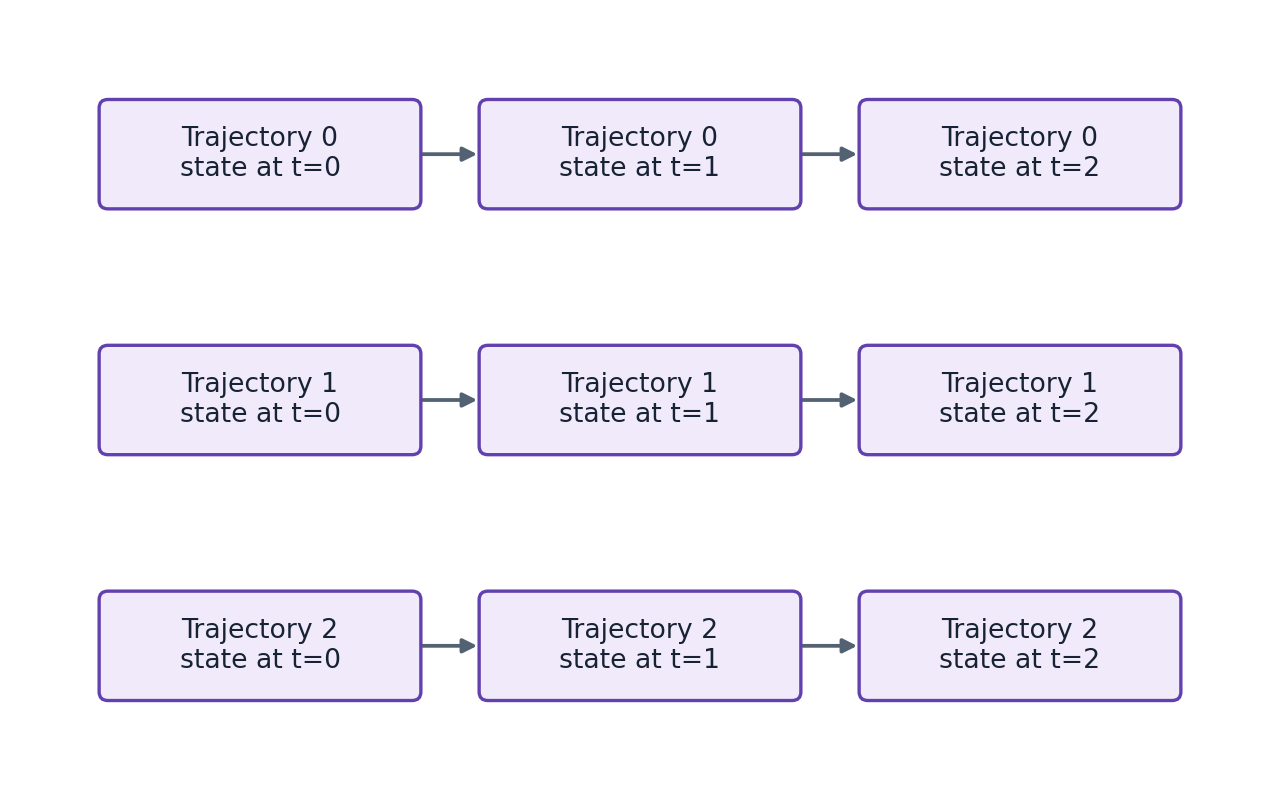

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

Each row is an independent initial condition. Horizontal arrows advance only that system; there are no cross-row state dependencies. Vectorization groups rows and scan represents recurrence. Boxes show state positions in the computation, not physical coordinates or measured durations.

### Pause and reason

What should happen if you permute independent initial conditions?

<details><summary>Compare your reasoning</summary>

The trajectories should undergo the same permutation, with each trajectory's time evolution unchanged. This checks independence and axis handling.

</details>

## Improve one step before multiplying trajectories

Forward Euler samples the slope only at the start of the interval. Classical RK4 samples a start slope, two midpoint slopes and an endpoint slope, then combines them with weights $1,2,2,1$. The intermediate states are trial values, not four extra saved observations. For our linear equation the full step is multiplication by a fourth-degree approximation to $e^{-kh}$. This makes an independent algebraic oracle possible.

$$
R(z)=1+z+\frac{z^2}{2}+\frac{z^3}{6}+\frac{z^4}{24},\qquad u_{n+1}=R(-kh)u_n
$$

## Read shapes as physical statements

Three initial values and forty updates produce a batch-major array of shape $(3,41)$. Row $b$ is one trajectory; column $n$ holds all experiment values at time $nh$. The extra time point is the initial state. We deliberately use different axis sizes to make an accidental transpose visible. A mean over the batch answers a different question from a mean over time.

## One transformation handles independence; another handles dependency

vmap transforms a scalar simulation into an ensemble operation. scan still enforces the sequential state dependence inside each trajectory. Reversing the composition is possible here: the carry can hold all three independent states, giving a time-major result of shape $(41,3)$. Its transpose matches the first construction. If one trajectory exchanges heat with another, the batch members no longer obey independent scalar equations; write a coupled vector state instead.

## Use physical structure as a second check

This equation is linear in the initial state. Starting at $2$ must produce four times the trajectory starting at $0.5$. That check is separate from the exponential comparison and catches unintended normalization over the batch axis. Linearity is special to this model; do not impose it on a nonlinear reaction model simply because batching worked here.

## Choose saved outputs deliberately

Saving every state costs storage proportional to batch size times number of saved times. Some objectives need only the final state. In that case return no saved observation from scan and keep its final carry. This reduces the explicit output size; it does not by itself establish the memory cost of reverse-mode differentiation, which may retain or recompute intermediates.

## Use a higher-order scalar transition

Append this block to main.py in your CPU course environment; for the first block create the file. Run blocks in order.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np

def rk4_step(rate, value, dt):
    a = -rate*value
    b = -rate*(value + dt*a/2)
    c = -rate*(value + dt*b/2)
    d = -rate*(value + dt*c)
    return value + dt*(a + 2*b + 2*c + d)/6

def solve(rate, initial, steps=40, dt=0.05):
    def advance(value, unused):
        next_value = rk4_step(rate, value, dt)
        return next_value, next_value
    _, tail = jax.lax.scan(advance, initial, None, length=steps)
    return jnp.concatenate((jnp.atleast_1d(initial), tail))

Runge–Kutta uses four slopes inside one step. It remains a pure transition, so the same scan interface can save its trajectory.

## Batch initial conditions while sharing the model

Append this block to main.py in your CPU course environment; for the first block create the file. Run blocks in order.

In [2]:
initials = jnp.array([0.5, 1.0, 2.0])
rate, dt, steps = 0.7, 0.05, 40
simulate_batch = jax.jit(jax.vmap(lambda initial: solve(rate, initial, steps, dt)))
trajectories = simulate_batch(initials)
times = np.arange(steps+1)*dt
oracle = np.asarray(initials)[:,None]*np.exp(-rate*times[None,:])
assert trajectories.shape == (3, 41)
np.testing.assert_allclose(trajectories, oracle, rtol=3e-8, atol=1e-10)
np.testing.assert_allclose(np.asarray(trajectories)[2], 4*np.asarray(trajectories)[0], rtol=1e-12)
print("Shape:", trajectories.shape, "endpoints:", np.asarray(trajectories)[:,-1])

Shape: (3, 41) endpoints: [0.12329848 0.24659697 0.49319394]


The batch axis is independent initial conditions, not time. The shared rate and grid are closed over here; vmap adds one leading axis to the scalar solve.

## Change composition and verify axis meaning

Append this block to main.py in your CPU course environment; for the first block create the file. Run blocks in order.

In [3]:
def scan_batch(rate, values, steps=40, dt=0.05):
    def advance(state, unused):
        updated = rk4_step(rate, state, dt)
        return updated, updated
    _, tail = jax.lax.scan(advance, values, None, length=steps)
    return jnp.concatenate((values[None,:], tail), axis=0)
time_major = scan_batch(rate, initials)
assert time_major.shape == (41, 3)
np.testing.assert_allclose(time_major.T, trajectories, rtol=1e-12, atol=1e-12)
print("scan(vectors) transposed equals vmap(scan)")

scan(vectors) transposed equals vmap(scan)


Array arithmetic applies the independent scalar dynamics to all initial conditions. This equivalence would fail if the model coupled different batch members.

## Run the example

In [4]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np

def rk4_step(rate, value, dt):
    a = -rate*value
    b = -rate*(value + dt*a/2)
    c = -rate*(value + dt*b/2)
    d = -rate*(value + dt*c)
    return value + dt*(a + 2*b + 2*c + d)/6

def solve(rate, initial, steps=40, dt=0.05):
    def advance(value, unused):
        next_value = rk4_step(rate, value, dt)
        return next_value, next_value
    _, tail = jax.lax.scan(advance, initial, None, length=steps)
    return jnp.concatenate((jnp.atleast_1d(initial), tail))

initials = jnp.array([0.5, 1.0, 2.0])
rate, dt, steps = 0.7, 0.05, 40
simulate_batch = jax.jit(jax.vmap(lambda initial: solve(rate, initial, steps, dt)))
trajectories = simulate_batch(initials)
times = np.arange(steps+1)*dt
oracle = np.asarray(initials)[:,None]*np.exp(-rate*times[None,:])
assert trajectories.shape == (3, 41)
np.testing.assert_allclose(trajectories, oracle, rtol=3e-8, atol=1e-10)
np.testing.assert_allclose(np.asarray(trajectories)[2], 4*np.asarray(trajectories)[0], rtol=1e-12)
print("Shape:", trajectories.shape, "endpoints:", np.asarray(trajectories)[:,-1])

def scan_batch(rate, values, steps=40, dt=0.05):
    def advance(state, unused):
        updated = rk4_step(rate, state, dt)
        return updated, updated
    _, tail = jax.lax.scan(advance, values, None, length=steps)
    return jnp.concatenate((values[None,:], tail), axis=0)
time_major = scan_batch(rate, initials)
assert time_major.shape == (41, 3)
np.testing.assert_allclose(time_major.T, trajectories, rtol=1e-12, atol=1e-12)
print("scan(vectors) transposed equals vmap(scan)")

Shape: (3, 41) endpoints: [0.12329848 0.24659697 0.49319394]
scan(vectors) transposed equals vmap(scan)


Expected: Shape (3, 41); endpoints approximately [0.12329849, 0.24659697, 0.49319394]. Both compositions agree.

## Batching preserves independent physical trajectories

Predict: Should the highest curve decay proportionally faster, or preserve its ratio to the other curves?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data={'kind':'line','x':times.tolist(),'xlabel':'time (seconds)','ylabel':'excess temperature','series':[{'label':f'initial {float(u):g}','y':np.asarray(trajectories)[i].tolist()} for i,u in enumerate(initials)]}

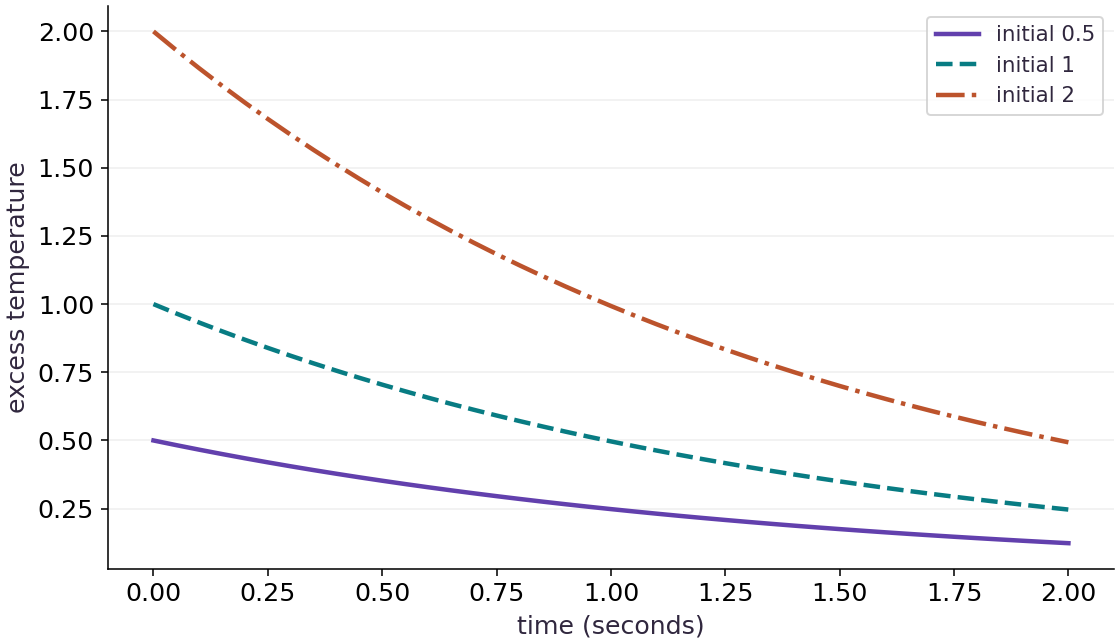

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Time in seconds runs horizontally; excess temperature runs vertically. The three curves correspond to initial values $0.5$, $1$ and $2$. Each is one row of the batch-major output, including its initial observation.

At two seconds their values are approximately $0.1233$, $0.2466$ and $0.4932$. Their absolute changes differ, but every curve retains the same fraction of its initial value. The highest remains four times the lowest throughout.

### Connect it to the computation

The common rate produces that shared relative decay. vmap adds independent experiments without inserting a mean, normalization or interaction between them. The code checks both this proportional relationship and the analytic exponential.

The plot has no runtime or memory axis. It establishes numerical behavior for this ensemble, not a speedup from vectorization. The last lesson adds synchronized measurements with their own limitations.

## Compare RK4 with an independent polynomial

Predict: If the step is correct, can a loop-free formula reproduce every saved state?

In [7]:
z = -rate*dt
multiplier = 1 + z + z*z/2 + z**3/6 + z**4/24
polynomial = np.asarray(initials)[:,None]*multiplier**np.arange(steps+1)[None,:]
np.testing.assert_allclose(trajectories, polynomial, rtol=1e-12, atol=1e-12)
print("RK4 polynomial maximum difference:", np.max(np.abs(np.asarray(trajectories)-polynomial)))

RK4 polynomial maximum difference: 1.4432899320127035e-15


Expected: Differences are near float64 roundoff.

This checks the discrete algorithm independently of the continuous exponential. RK4 has much smaller error here but is not exact.

## Let each trajectory have its own rate

Predict: Which argument axes should map if rates and initial conditions are paired?

In [8]:
rates = jnp.array([0.2, 0.7, 1.1])
paired = jax.vmap(lambda k, u: solve(k,u), in_axes=(0,0))(rates,initials)
paired_reference = np.asarray(initials)[:,None]*np.exp(-np.asarray(rates)[:,None]*times)
np.testing.assert_allclose(paired,paired_reference,rtol=2e-7,atol=1e-10)
print("Paired-rate endpoints:", np.asarray(paired)[:,-1])

Paired-rate endpoints: [0.33516002 0.24659697 0.22160636]


Expected: Three trajectories now have different relative decay rates.

Mapping both axes pairs corresponding entries. A grid of every rate with every initial value would require nested mapping and a different output contract.

## Your exercise

Add a fourth initial condition, verify the changed output shape and exponential values, then verify that reordering initial conditions reorders rows only.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
changed_initials = jnp.array([0.5, 1.0, 2.0, 3.0])
changed = jax.vmap(lambda u: solve(0.7,u))(changed_initials)
assert changed.shape == (4,41)
np.testing.assert_allclose(changed,np.asarray(changed_initials)[:,None]*np.exp(-0.7*times),rtol=3e-8)
order = jnp.array([3,0,2,1])
reordered = jax.vmap(lambda u: solve(0.7,u))(changed_initials[order])
np.testing.assert_allclose(reordered,changed[order],rtol=1e-12)
print("Permutation preserves trajectory identity")

Permutation preserves trajectory identity


## Save only what the objective needs · Practice

Implement a final-state-only solve and compare it with the final column of the saved batch. Explain which allocation was removed.

Hint: scan may emit None while its carry still advances.

In [11]:
# Write your attempt here.

## Reference reasoning

The explicit trajectory output is removed. Differentiation memory requires separate analysis and measurement.

In [12]:
def final_only(rate, initial, steps=40, dt=0.05):
    def advance(value, unused):
        return rk4_step(rate,value,dt), None
    return jax.lax.scan(advance,initial,None,length=steps)[0]
finals = jax.vmap(lambda u: final_only(0.7,u))(initials)
np.testing.assert_allclose(finals,trajectories[:,-1],rtol=1e-12)
print("Only final states returned:", np.asarray(finals))

Only final states returned: [0.12329848 0.24659697 0.49319394]


## Pairing versus Cartesian products · Challenge

Build the full grid of three rates and three initial values. Show that its diagonal agrees with the paired-rate experiment.

Hint: Use nested vmap; identify the rate, initial-condition and time axes explicitly.

In [13]:
# Write your attempt here.

## Reference reasoning

Paired batches and Cartesian products are different experiments. The diagonal correspondence verifies the axis interpretation.

In [14]:
grid = jax.vmap(lambda k: jax.vmap(lambda u: solve(k,u))(initials))(rates)
assert grid.shape == (3,3,41)
np.testing.assert_allclose(grid[jnp.arange(3),jnp.arange(3)],paired,rtol=1e-12)
print("Grid axes: rate, initial condition, time", grid.shape)

Grid axes: rate, initial condition, time (3, 3, 41)


## Checkpoint

What does a shape of (3, 41) mean in the batch-major solver?

1. Three independent initial conditions, each with the initial state plus forty updates.
2. Three time points, each with forty-one parameters.
3. Forty-one independent devices.

## Diagnose

If the reference comparison broadcasts unexpectedly, print both shapes before reducing anything. Compare a named row and a named time column. If changing one initial condition changes other rows, inspect reductions or coupling across the batch. A reduction can hide an axis error while still producing a plausible scalar.

## Evidence

Polynomial/exponential references, batch/time shape diagram, permutation and final-only checks. Keep the environment, observed outputs and your explanation of the figure.

## Carry forward

- Improve one step before multiplying trajectories
- Read shapes as physical statements
- One transformation handles independence; another handles dependency
- Use physical structure as a second check
- Choose saved outputs deliberately

## Primary references

- [JAX scan: fixed carry structure and reverse-mode differentiation](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html)
- [JAX automatic vectorization](https://docs.jax.dev/en/latest/_autosummary/jax.vmap.html)
- [JAX derivative checking and Jacobian products](https://docs.jax.dev/en/latest/notebooks/autodiff_cookbook.html)
- [Diffrax solver terms, saved values and solution inspection](https://docs.kidger.site/diffrax/usage/getting-started/)